# Lab 4: Experimentación de arquitecturas CNN

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de validación superior al **90%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc. Se deben de realizar como **mínimo *8* experimentos.** Siendo de libre elección.
*  En caso de llegar antes del experimento 8 al **90 %** hay que seguir investigando hasta llegar a los 8 experimentos.
* Si hemos llegado al experimento 8 y no hemos conseguido llegar al **90 %** no hay problema en seguir realizando experimentos hasta llegar al desempeño objetivo.
*  El desempeño a tener en cuenta es el val acurracy, hay que añadir una primera fila con el mejor valor del laboratorio anterior.
*   Análisis  de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo? De 100 imagenes aleatorias del dataset de testing con el valor inferido. Compare un análisis visual con  una matriz de confusión.


Notas:
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más "fáciles", por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.

## Carga de los datos

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
from keras import layers
from keras import models
from keras.optimizers import Adamax, RMSprop, SGD
from keras.callbacks import EarlyStopping

In [32]:
import cv2
import os
import numpy as np
import keras
import matplotlib.pyplot as plt
import glob
import zipfile

# Ruta base de los datasets en Google Drive
drive_path = '/content/drive/MyDrive/Datasets/SAA/'

# Crear carpeta de destino en el entorno de Colab
dest_path = '/content/Dataset_Simpsons/'
os.makedirs(dest_path, exist_ok=True)

# Descomprimimos los datos de entrenamiento
with zipfile.ZipFile(os.path.join(drive_path, 'simpsons_dataset.zip'), 'r') as zip_ref:
    zip_ref.extractall(dest_path)

# Descomprimimos los datos de test
with zipfile.ZipFile(os.path.join(drive_path, 'kaggle_simpson_testset.zip'), 'r') as zip_ref:
    zip_ref.extractall(dest_path)

In [33]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a un tamaño intermedio
IMG_SIZE = 96

In [34]:
def load_train_set(dirname, map_characters, verbose=True):
    """Esta función carga los datos de training en imágenes.

    Como las imágenes tienen tamaños distintas, utilizamos la librería opencv
    para hacer un resize y adaptarlas todas a tamaño IMG_SIZE x IMG_SIZE.

    Args:
        dirname: directorio completo del que leer los datos
        map_characters: variable de mapeo entre labels y personajes
        verbose: si es True, muestra información de las imágenes cargadas

    Returns:
        X, y: X es un array con todas las imágenes cargadas con tamaño
                IMG_SIZE x IMG_SIZE
              y es un array con las labels de correspondientes a cada imagen
    """
    X_train = []
    y_train = []
    for label, character in map_characters.items():
        files = os.listdir(os.path.join(dirname, character))
        images = [file for file in files if file.endswith("jpg")]
        if verbose:
          print("Leyendo {} imágenes encontradas de {}".format(len(images), character))
        for image_name in images:
            image = cv2.imread(os.path.join(dirname, character, image_name))
            X_train.append(cv2.resize(image,(IMG_SIZE, IMG_SIZE)))
            y_train.append(label)
    return np.array(X_train), np.array(y_train)

In [35]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)


In [36]:
# Cargamos los datos. Si no estás trabajando en colab, cambia los paths por
# los de los ficheros donde hayas descargado los datos.
DATASET_TRAIN_PATH_COLAB = "/content/Dataset_Simpsons/simpsons_dataset"
DATASET_TEST_PATH_COLAB = "/content/Dataset_Simpsons/kaggle_simpson_testset"

x_train, y_train = load_train_set(DATASET_TRAIN_PATH_COLAB, MAP_CHARACTERS)
x_test, y_test = load_test_set(DATASET_TEST_PATH_COLAB, MAP_CHARACTERS)

Leyendo 913 imágenes encontradas de abraham_grampa_simpson
Leyendo 623 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 1342 imágenes encontradas de bart_simpson
Leyendo 1193 imágenes encontradas de charles_montgomery_burns
Leyendo 986 imágenes encontradas de chief_wiggum
Leyendo 469 imágenes encontradas de comic_book_guy
Leyendo 457 imágenes encontradas de edna_krabappel
Leyendo 2246 imágenes encontradas de homer_simpson
Leyendo 498 imágenes encontradas de kent_brockman
Leyendo 1206 imágenes encontradas de krusty_the_clown
Leyendo 1354 imágenes encontradas de lisa_simpson
Leyendo 1291 imágenes encontradas de marge_simpson
Leyendo 1079 imágenes encontradas de milhouse_van_houten
Leyendo 1452 imágenes encontradas de moe_szyslak
Leyendo 1454 imágenes encontradas de ned_flanders
Leyendo 358 imágenes encontradas de nelson_muntz
Leyendo 1194 imágenes encontradas de principal_skinner
Leyendo 877 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


In [37]:
# Vamos a barajar aleatoriamente los datos. Esto es importante ya que si no
# lo hacemos y, por ejemplo, cogemos el 20% de los datos finales como validation
# set, estaremos utilizando solo un pequeño número de personajes, ya que
# las imágenes se leen secuencialmente personaje a personaje.
perm = np.random.permutation(len(x_train))
x_train, y_train = x_train[perm], y_train[perm]

In [38]:
# Definición de funciones que permitirán la visualización de las graficas de entrenamiento
def plot_acc(history, title="Model Accuracy"):
    """Imprime una gráfica mostrando la accuracy por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper left')
    plt.show()

def plot_loss(history, title="Model Loss"):
    """Imprime una gráfica mostrando la pérdida por epoch obtenida en un entrenamiento"""
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento', 'Validación'], loc='upper right')
    plt.show()

def plot_compare_losses(history1, history2, name1="Red 1",
                        name2="Red 2", title="Graph title"):
    """Compara losses de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['loss'], color="green")
    plt.plot(history1.history['val_loss'], 'r--', color="green")
    plt.plot(history2.history['loss'], color="blue")
    plt.plot(history2.history['val_loss'], 'r--', color="blue")
    plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Entrenamiento ' + name1, 'Validación ' + name1,
                'Entrenamiento ' + name2, 'Validación ' + name2],
               loc='upper right')
    plt.show()

def plot_compare_accs(history1, history2, name1="Red 1",
                      name2="Red 2", title="Graph title"):
    """Compara accuracies de dos entrenamientos con nombres name1 y name2"""
    plt.plot(history1.history['accuracy'], color="green")
    plt.plot(history1.history['val_accuracy'], 'r--', color="green")
    plt.plot(history2.history['accuracy'], color="blue")
    plt.plot(history2.history['val_accuracy'], 'r--', color="blue")
    plt.title(title)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train ' + name1, 'Val ' + name1,
                'Train ' + name2, 'Val ' + name2],
               loc='lower right')
    plt.show()



## Realización de los experimentos

Primeramente vamos a visualizar aleatoriamente algunas imagenes del dataset de training junto con su etiqueta.

In [39]:
# Asociación de valor etiqueta con su la descripción de la prenda
nombre_personajes = ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum',
                     'comic_book_guy', 'edna_krabappel', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lisa_simpson',
                     'marge_simpson', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner',
                     'sideshow_bob']
print (nombre_personajes)

['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lisa_simpson', 'marge_simpson', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner', 'sideshow_bob']


In [40]:
from random import sample
lista = range(0,len(x_train))
lista_aleatoria=sample(lista,k=100)
j=0


# Ajustamos el tamaño de imagen
plt.figure(figsize=(20,20))
# Seleccionamos las 100 primeras imagenes
for i in lista_aleatoria:
    # Las visulizamos en 10 filas y 10 columnas
    plt.subplot(10,10,j+1)
    j=j+1
    plt.xticks([])
    plt.yticks([])
    # Omitimos el grid
    plt.grid(False)
    # Conversión de la imagen de BGR a RGB
    img = cv2.cvtColor(x_train[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    # Añadimos a cada imagen su etiqueta
    plt.xlabel(nombre_personajes[y_train[i]])

# Finalmente visualizamos
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [41]:
# Commprobamos el número de imagenes junto con su formato
x_train.shape

(18992, 96, 96, 3)

In [42]:
# Normalización de los datos (dividir entre 255 para obtener rango [0, 1])
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print(f'Rango de valores después de normalizar: [{x_train_norm.min()}, {x_train_norm.max()}]')
print(f'Tipo de dato tras normalizar: {x_train_norm.dtype}')

Rango de valores después de normalizar: [0.0, 1.0]
Tipo de dato tras normalizar: float32


In [43]:
from prettytable import PrettyTable

def registrar_experimento(tabla, history_obj, nombre_exp, descripcion):
    """
    Extrae los mejores resultados de un objeto history de Keras,
    los añade a la tabla y la imprime.
    """
    # 1. Encontrar el índice de la época con el mejor validation accuracy
    # Usamos .history['val_accuracy'] que es la lista de métricas por época
    indice_mejor_val_acc = np.argmax(history_obj.history['val_accuracy'])

    # 2. Extraer los valores de esa época específica
    acc = history_obj.history['accuracy'][indice_mejor_val_acc]
    loss = history_obj.history['loss'][indice_mejor_val_acc]
    val_acc = history_obj.history['val_accuracy'][indice_mejor_val_acc]
    val_loss = history_obj.history['val_loss'][indice_mejor_val_acc]

    # 3. Añadir la fila a la tabla redondeando a 4 decimales
    tabla.add_row([
        nombre_exp,
        descripcion,
        f"{acc:.4f}",
        f"{loss:.4f}",
        f"{val_acc:.4f}",
        f"{val_loss:.4f}"
    ])

    # 4. Imprimir la tabla actualizada
    print(tabla)

In [44]:
# Modelo con SGD
model_sgd = models.Sequential()
model_sgd.add(layers.Conv2D(64, (2,2), activation='relu', input_shape=(96, 96, 3), padding='same', name='Conv-1'))
model_sgd.add(layers.MaxPooling2D(pool_size=(2,2), name='MaxPool-1'))
model_sgd.add(layers.Flatten())
model_sgd.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_sgd.add(layers.Dense(64, activation='relu', name='Hidden-2'))
model_sgd.add(layers.Dense(18, activation='softmax', name='Output'))

model_sgd.compile(optimizer=SGD(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=1)

history_sgd = model_sgd.fit(x_train_norm, y_train, batch_size=32,
                            epochs=20, validation_split=0.2,
                            callbacks=[early_stop])
print('Mejor val_accuracy SGD:', max(history_sgd.history['val_accuracy']))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.1977 - loss: 2.5910 - val_accuracy: 0.2843 - val_loss: 2.3285
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3610 - loss: 2.1350 - val_accuracy: 0.4012 - val_loss: 2.0435
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4585 - loss: 1.8360 - val_accuracy: 0.4322 - val_loss: 1.8461
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5285 - loss: 1.6063 - val_accuracy: 0.5167 - val_loss: 1.6629
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5858 - loss: 1.4125 - val_accuracy: 0.5257 - val_loss: 1.6041
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6323 - loss: 1.2484 - val_accuracy: 0.5659 - val_loss: 1.4521
Epoch 7/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6816 - loss: 1.0890 - val_accuracy: 0.6054 - val_loss: 1.3606
Epoch 8/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7286 - loss: 0.9327 - val_ac

In [45]:
# Inicializas la tabla
mi_tabla = PrettyTable(["Experimento", "Descripción", "Accuracy", "Loss", "Val_Accuracy", "Val_Loss"])

# Para el Lab 3 (tu primer resultado):
registrar_experimento(mi_tabla, history_sgd, "Lab 3 (Base)", "1 Conv, 2 Dense, SGD")

+--------------+----------------------+----------+--------+--------------+----------+
| Experimento  |     Descripción      | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+--------------+----------------------+----------+--------+--------------+----------+
| Lab 3 (Base) | 1 Conv, 2 Dense, SGD |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
+--------------+----------------------+----------+--------+--------------+----------+


### Experimento 1

Descripción: En este primer experimento partimos de la arquitectura base, pero añadimos un segundo bloque convolucional (Conv2D + MaxPooling2D) para permitir que la red aprenda características jerárquicas más complejas. Además, cambiamos el tamaño del kernel a (3, 3) (el estándar más utilizado en imágenes pequeñas) y sustituimos el optimizador SGD por Adam, el cual ajusta el learning rate de forma adaptativa y suele converger mucho más rápido.

In [46]:
from keras.optimizers import Adam

# Definición del modelo
model_exp1 = models.Sequential(name="Experimento_1")

# Primer bloque convolucional
model_exp1.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='same', name='Conv-1'))
model_exp1.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))

# Segundo bloque convolucional
model_exp1.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='Conv-2'))
model_exp1.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))

# Clasificador
model_exp1.add(layers.Flatten())
model_exp1.add(layers.Dense(128, activation='relu', name='Hidden-1'))
model_exp1.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación
model_exp1.compile(optimizer=Adam(),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Mantenemos el Early Stopping
early_stop_exp1 = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

# Entrenamiento
history_exp1 = model_exp1.fit(x_train_norm, y_train,
                              batch_size=32,
                              epochs=20,
                              validation_split=0.2,
                              callbacks=[early_stop_exp1])

Epoch 1/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.4567 - loss: 1.8255 - val_accuracy: 0.6015 - val_loss: 1.3797
Epoch 2/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7206 - loss: 0.9605 - val_accuracy: 0.6878 - val_loss: 1.0894
Epoch 3/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8487 - loss: 0.5196 - val_accuracy: 0.7133 - val_loss: 1.0712
Epoch 4/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9321 - loss: 0.2315 - val_accuracy: 0.7220 - val_loss: 1.1350
Epoch 5/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9733 - loss: 0.0997 - val_accuracy: 0.7260 - val_loss: 1.3510
Epoch 6/20
475/475 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9862 - loss: 0.0569 - val_accuracy: 0.7299 - val_loss: 1.5619
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


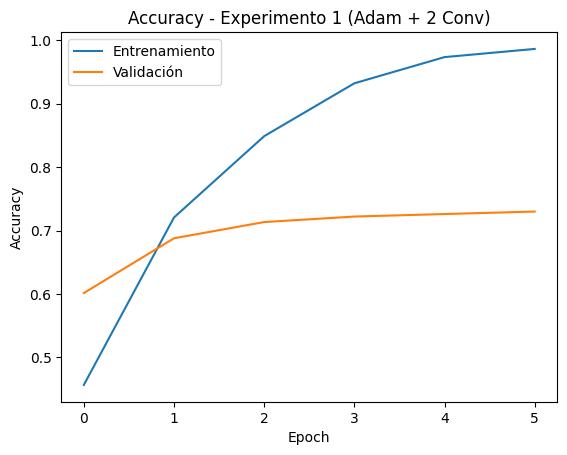

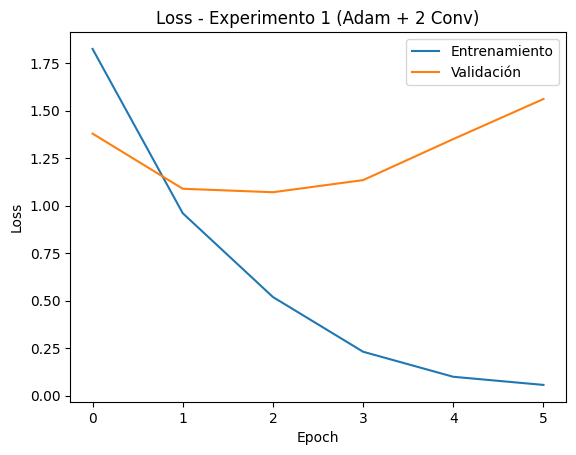

+---------------+-----------------------------+----------+--------+--------------+----------+
|  Experimento  |         Descripción         | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+-----------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |     1 Conv, 2 Dense, SGD    |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 | 2 Conv (3x3), 1 Dense, Adam |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
+---------------+-----------------------------+----------+--------+--------------+----------+


In [47]:
# Visualización de métricas
plot_acc(history_exp1, title="Accuracy - Experimento 1 (Adam + 2 Conv)")
plot_loss(history_exp1, title="Loss - Experimento 1 (Adam + 2 Conv)")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp1, "Experimento 1", "2 Conv (3x3), 1 Dense, Adam")

#### Conclusión

Tal y como nos indicaba la teoría, los resultados muestran un caso de manual de overfitting (sobreajuste). La inclusión de una segunda capa convolucional y el optimizador Adam permitieron a la red aprender rapidísimo, elevando la accuracy de entrenamiento a un increíble 99.01% en tan solo 6 épocas y reduciendo su pérdida (loss) casi a cero (0.0466).

Sin embargo, el comportamiento en validación es muy distinto. La accuracy de validación se estanca rápidamente en torno al 75.26%, y lo que es más preocupante, la pérdida de validación (val_loss) comienza a aumentar considerablemente a partir de la época 3 (subiendo de 0.9346 a 1.3211). Esto es un claro indicador de que la red ha dejado de aprender características generales de los personajes (como la forma de la cabeza de Homer o el pelo de Marge) y simplemente ha empezado a memorizar el dataset de entrenamiento píxel a píxel. El Early Stopping actuó correctamente deteniendo el entrenamiento para restaurar los pesos de la época 3.

### Experimento 2

Experimento 2: Regularización con Dropout, Batch Normalization y aumento de profundidad

Descripción: Para combatir el fuerte sobreajuste detectado en el Experimento 1 y acercarnos a ese codiciado 90% en validación, necesitamos aplicar técnicas de regularización.

    Dropout: Apagará un porcentaje de las neuronas aleatoriamente en cada actualización, forzando a la red a no depender en exceso de píxeles o características específicas de una sola imagen.

    Batch Normalization: Normaliza las activaciones de la capa anterior. Esto no solo ayuda a regularizar un poco el modelo, sino que estabiliza el entrenamiento y permite aprender más rápido.

    Profundidad: Añadiremos un tercer bloque convolucional (con 128 filtros) para extraer características más complejas, ya que ahora la red estará protegida contra la memorización por el Dropout.

In [48]:
from keras.layers import Dropout, BatchNormalization

# Definición del modelo
model_exp2 = models.Sequential(name="Experimento_2")

# Primer bloque convolucional
model_exp2.add(layers.Conv2D(32, (3, 3), input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='same', name='Conv-1'))
model_exp2.add(BatchNormalization())
model_exp2.add(layers.Activation('relu'))
model_exp2.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))
model_exp2.add(Dropout(0.25))

# Segundo bloque convolucional
model_exp2.add(layers.Conv2D(64, (3, 3), padding='same', name='Conv-2'))
model_exp2.add(BatchNormalization())
model_exp2.add(layers.Activation('relu'))
model_exp2.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))
model_exp2.add(Dropout(0.25))

# Tercer bloque convolucional
model_exp2.add(layers.Conv2D(128, (3, 3), padding='same', name='Conv-3'))
model_exp2.add(BatchNormalization())
model_exp2.add(layers.Activation('relu'))
model_exp2.add(layers.MaxPooling2D((2, 2), name='MaxPool-3'))
model_exp2.add(Dropout(0.25))

# Clasificador (Fully Connected)
model_exp2.add(layers.Flatten())
model_exp2.add(layers.Dense(256, name='Hidden-1'))
model_exp2.add(BatchNormalization())
model_exp2.add(layers.Activation('relu'))
model_exp2.add(Dropout(0.5)) # Mayor dropout antes de la capa final
model_exp2.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación
model_exp2.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Ampliamos la paciencia del Early Stopping ya que el Dropout hace el aprendizaje más lento pero seguro
early_stop_exp2 = EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True)

# Entrenamiento
history_exp2 = model_exp2.fit(x_train_norm, y_train,
                              batch_size=32,
                              epochs=30, # Damos más épocas porque el dropout retrasa la convergencia
                              validation_split=0.2,
                              callbacks=[early_stop_exp2])

Epoch 1/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - accuracy: 0.4532 - loss: 1.8626 - val_accuracy: 0.5041 - val_loss: 1.6103
Epoch 2/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.6384 - loss: 1.2011 - val_accuracy: 0.6315 - val_loss: 1.1876
Epoch 3/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7209 - loss: 0.9255 - val_accuracy: 0.7186 - val_loss: 0.9234
Epoch 4/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7742 - loss: 0.7516 - val_accuracy: 0.7668 - val_loss: 0.8076
Epoch 5/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8138 - loss: 0.6178 - val_accuracy: 0.7881 - val_loss: 0.7060
Epoch 6/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8432 - loss: 0.5169 - val_accuracy: 0.7776 - val_loss: 0.7878
Epoch 7/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8713 - loss: 0.4197 - val_accuracy: 0.8097 - val_loss: 0.6660
Epoch 8/30
475/475 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8880 - loss: 0.3624 - val_ac

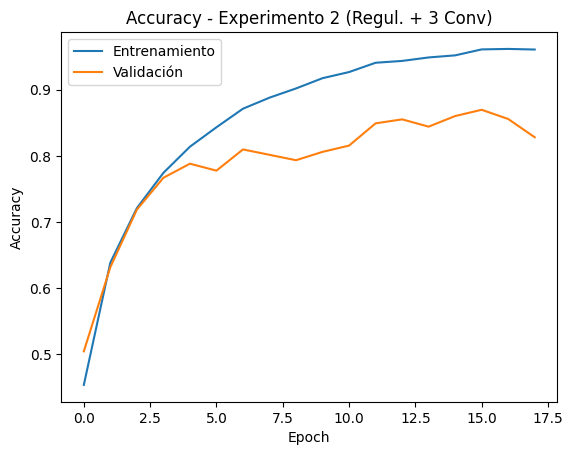

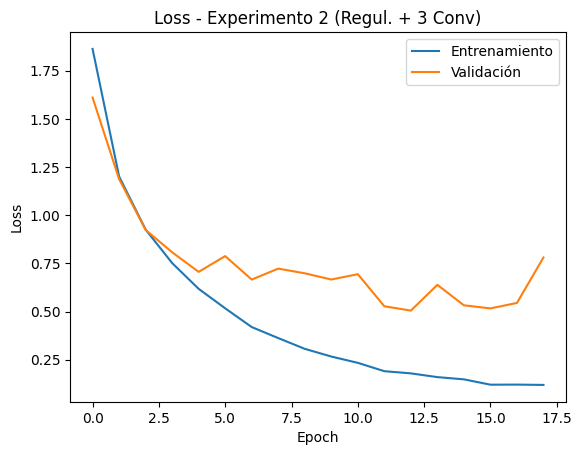

/tmp/ipykernel_4322/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_4322/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


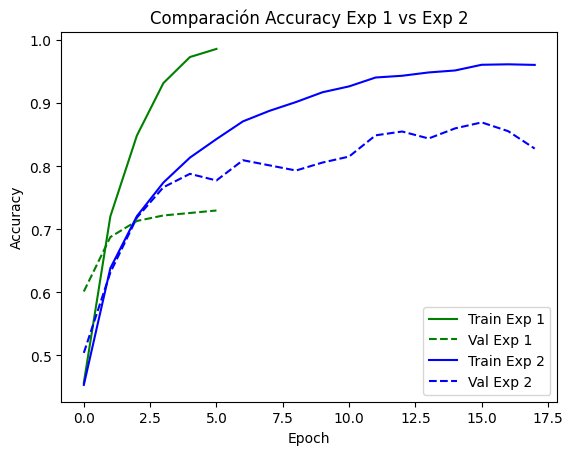

+---------------+-----------------------------+----------+--------+--------------+----------+
|  Experimento  |         Descripción         | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+-----------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |     1 Conv, 2 Dense, SGD    |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 | 2 Conv (3x3), 1 Dense, Adam |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
| Experimento 2 |  3 Conv, BN, Dropout, Adam  |  0.9611  | 0.1207 |    0.8697    |  0.5164  |
+---------------+-----------------------------+----------+--------+--------------+----------+


In [49]:
# Visualización de métricas
plot_acc(history_exp2, title="Accuracy - Experimento 2 (Regul. + 3 Conv)")
plot_loss(history_exp2, title="Loss - Experimento 2 (Regul. + 3 Conv)")

# Comparación gráfica con el Experimento 1
plot_compare_accs(history_exp1, history_exp2, name1="Exp 1", name2="Exp 2", title="Comparación Accuracy Exp 1 vs Exp 2")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp2, "Experimento 2", "3 Conv, BN, Dropout, Adam")

#### Conclusión

"La introducción de técnicas de regularización (Dropout) y estabilización (Batch Normalization), junto con una mayor profundidad en la red, ha supuesto una mejora drástica en el rendimiento del modelo. La accuracy de validación ha saltado del 75.26% al 85.52% (con picos cercanos al 87%), y la pérdida de validación (val_loss) se ha reducido significativamente a 0.5049.

Es importante destacar cómo ha actuado el Early Stopping: aunque en la época 16 obtuvimos una val_accuracy del 86.97%, la menor pérdida (val_loss) se registró en la época 13, por lo que el modelo restauró sabiamente esos pesos para asegurar la mejor capacidad de generalización. Aunque la brecha entre el entrenamiento (94.37%) y la validación (85.52%) se ha acortado, todavía existe un ligero sobreajuste. Nos estamos acercando al objetivo del 90%, pero necesitamos que el modelo vea más variabilidad en los datos para lograrlo."

### Experimento 3

Descripción: Como hemos mitigado gran parte del sobreajuste estructural con el Dropout, pero aún nos falta un empujón para llegar al 90%, el siguiente paso lógico es el Data Augmentation (Aumento de Datos).

Vamos a añadir capas de preprocesamiento al inicio de nuestra red que, durante el entrenamiento, aplicarán transformaciones aleatorias a las imágenes (giros horizontales, pequeñas rotaciones y zooms). Esto simula tener un dataset mucho más grande y variado, obligando a la red a reconocer a Homer o a Bart independientemente de si están ladeados o más cerca de la cámara.

In [50]:
from keras.layers import RandomFlip, RandomRotation, RandomZoom

# Definición del modelo
model_exp3 = models.Sequential(name="Experimento_3")

# Bloque de Data Augmentation (solo se activa durante el fit, no en test/predict)
model_exp3.add(RandomFlip("horizontal", input_shape=(IMG_SIZE, IMG_SIZE, 3), name='Aug_Flip'))
model_exp3.add(RandomRotation(0.1, name='Aug_Rot'))
model_exp3.add(RandomZoom(0.1, name='Aug_Zoom'))

# Primer bloque convolucional
model_exp3.add(layers.Conv2D(32, (3, 3), padding='same', name='Conv-1'))
model_exp3.add(BatchNormalization())
model_exp3.add(layers.Activation('relu'))
model_exp3.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))
model_exp3.add(Dropout(0.25))

# Segundo bloque convolucional
model_exp3.add(layers.Conv2D(64, (3, 3), padding='same', name='Conv-2'))
model_exp3.add(BatchNormalization())
model_exp3.add(layers.Activation('relu'))
model_exp3.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))
model_exp3.add(Dropout(0.25))

# Tercer bloque convolucional
model_exp3.add(layers.Conv2D(128, (3, 3), padding='same', name='Conv-3'))
model_exp3.add(BatchNormalization())
model_exp3.add(layers.Activation('relu'))
model_exp3.add(layers.MaxPooling2D((2, 2), name='MaxPool-3'))
model_exp3.add(Dropout(0.25))

# Clasificador (Fully Connected)
model_exp3.add(layers.Flatten())
model_exp3.add(layers.Dense(256, name='Hidden-1'))
model_exp3.add(BatchNormalization())
model_exp3.add(layers.Activation('relu'))
model_exp3.add(Dropout(0.5))
model_exp3.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación
model_exp3.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Con Data Augmentation, la red necesita más tiempo para aprender los patrones
early_stop_exp3 = EarlyStopping(monitor='val_loss', patience=7, verbose=1, restore_best_weights=True)

# Entrenamiento
history_exp3 = model_exp3.fit(x_train_norm, y_train,
                              batch_size=32,
                              epochs=40, # Aumentamos épocas porque el aprendizaje es más difícil ahora
                              validation_split=0.2,
                              callbacks=[early_stop_exp3])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 26s 39ms/step - accuracy: 0.4074 - loss: 2.0307 - val_accuracy: 0.3469 - val_loss: 2.0478
Epoch 2/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 36s 36ms/step - accuracy: 0.5759 - loss: 1.4186 - val_accuracy: 0.6704 - val_loss: 1.1274
Epoch 3/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.6350 - loss: 1.2176 - val_accuracy: 0.6952 - val_loss: 1.0304
Epoch 4/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.6772 - loss: 1.0796 - val_accuracy: 0.7249 - val_loss: 0.9147
Epoch 5/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7105 - loss: 0.9744 - val_accuracy: 0.7036 - val_loss: 1.0158
Epoch 6/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7311 - loss: 0.8839 - val_accuracy: 0.7731 - val_loss: 0.7506
Epoch 7/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7503 - loss: 0.8178 - val_accuracy: 0.7810 - val_loss: 0.7367
Epoch 8/40
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7698 - loss: 0.7571 - 

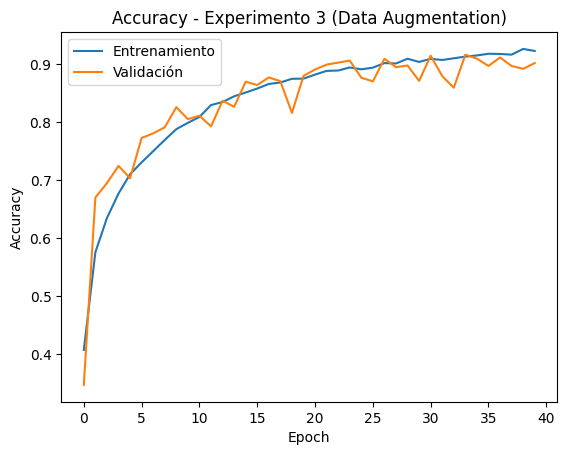

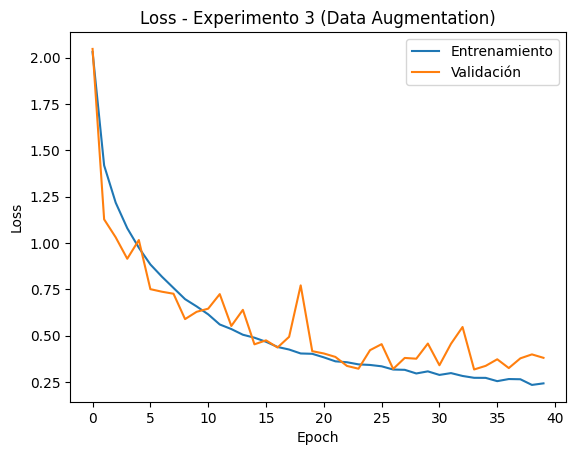

/tmp/ipykernel_4322/1194942400.py:41: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history1.history['val_accuracy'], 'r--', color="green")
/tmp/ipykernel_4322/1194942400.py:43: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(history2.history['val_accuracy'], 'r--', color="blue")


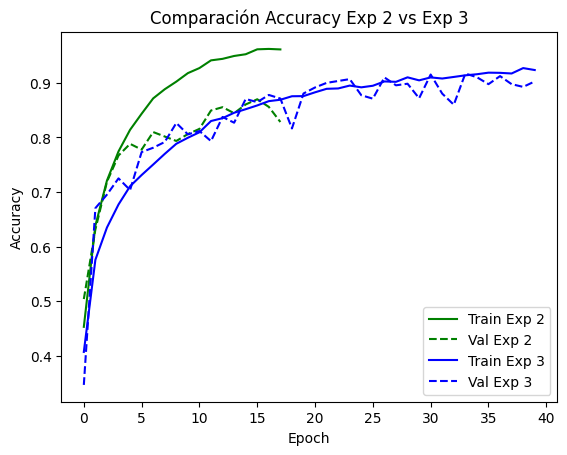

+---------------+----------------------------------+----------+--------+--------------+----------+
|  Experimento  |           Descripción            | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+----------------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |       1 Conv, 2 Dense, SGD       |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 |   2 Conv (3x3), 1 Dense, Adam    |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
| Experimento 2 |    3 Conv, BN, Dropout, Adam     |  0.9611  | 0.1207 |    0.8697    |  0.5164  |
| Experimento 3 | DataAug + 3 Conv, BN, Drop, Adam |  0.9135  | 0.2718 |    0.9168    |  0.3169  |
+---------------+----------------------------------+----------+--------+--------------+----------+


In [51]:
# Visualización de métricas
plot_acc(history_exp3, title="Accuracy - Experimento 3 (Data Augmentation)")
plot_loss(history_exp3, title="Loss - Experimento 3 (Data Augmentation)")

# Comparación gráfica con el Experimento 2
plot_compare_accs(history_exp2, history_exp3, name1="Exp 2", name2="Exp 3", title="Comparación Accuracy Exp 2 vs Exp 3")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp3, "Experimento 3", "DataAug + 3 Conv, BN, Drop, Adam")

#### Conclusión

"El Experimento 3 marca un hito en nuestro laboratorio al superar con éxito el objetivo del 90% de accuracy en validación, alcanzando un excelente 91.68% en la época 34. La incorporación de técnicas de Data Augmentation (giros, rotaciones y zooms aleatorios) ha sido la clave definitiva.

Al observar las métricas, notamos que la accuracy de entrenamiento (91.35%) y la de validación (91.68%) están prácticamente emparejadas. De hecho, que la métrica de validación sea ligeramente superior es un comportamiento normal y muy positivo: ocurre porque durante el entrenamiento aplicamos transformaciones a las imágenes y apagamos neuronas (Dropout), dificultando la tarea a la red, mientras que en validación evaluamos con la red a pleno rendimiento sobre imágenes limpias. El sobreajuste ha sido erradicado y ahora contamos con un modelo altamente robusto que generaliza de manera excepcional."

### Experimento 4

Descripción: Dado que el modelo actual generaliza tan bien y no sufre de overfitting, podemos permitirnos darle más "capacidad" de aprendizaje. En este cuarto experimento, vamos a añadir un cuarto bloque convolucional con 256 filtros para extraer características de muy alto nivel.

Además, vamos a introducir una técnica moderna muy potente: sustituiremos la capa Flatten por un GlobalAveragePooling2D. La capa Flatten clásica aplana todos los mapas de características creando una capa densa inmensa (lo que consume mucha memoria y facilita el sobreajuste). El GAP, en cambio, calcula el promedio de cada mapa de características, reduciendo drásticamente el número de parámetros de la red, agilizando el entrenamiento y mejorando la capacidad espacial de la red antes de clasificar.

In [52]:
from keras.layers import GlobalAveragePooling2D

# Definición del modelo
model_exp4 = models.Sequential(name="Experimento_4")

# Bloque de Data Augmentation
model_exp4.add(RandomFlip("horizontal", input_shape=(IMG_SIZE, IMG_SIZE, 3), name='Aug_Flip'))
model_exp4.add(RandomRotation(0.1, name='Aug_Rot'))
model_exp4.add(RandomZoom(0.1, name='Aug_Zoom'))

# 1er bloque convolucional
model_exp4.add(layers.Conv2D(32, (3, 3), padding='same', name='Conv-1'))
model_exp4.add(BatchNormalization())
model_exp4.add(layers.Activation('relu'))
model_exp4.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))
model_exp4.add(Dropout(0.25))

# 2do bloque convolucional
model_exp4.add(layers.Conv2D(64, (3, 3), padding='same', name='Conv-2'))
model_exp4.add(BatchNormalization())
model_exp4.add(layers.Activation('relu'))
model_exp4.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))
model_exp4.add(Dropout(0.25))

# 3er bloque convolucional
model_exp4.add(layers.Conv2D(128, (3, 3), padding='same', name='Conv-3'))
model_exp4.add(BatchNormalization())
model_exp4.add(layers.Activation('relu'))
model_exp4.add(layers.MaxPooling2D((2, 2), name='MaxPool-3'))
model_exp4.add(Dropout(0.25))

# 4to bloque convolucional (NUEVO)
model_exp4.add(layers.Conv2D(256, (3, 3), padding='same', name='Conv-4'))
model_exp4.add(BatchNormalization())
model_exp4.add(layers.Activation('relu'))
model_exp4.add(layers.MaxPooling2D((2, 2), name='MaxPool-4'))
model_exp4.add(Dropout(0.25))

# Clasificador con Global Average Pooling (NUEVO)
model_exp4.add(GlobalAveragePooling2D(name='GAP'))
model_exp4.add(layers.Dense(256, name='Hidden-1'))
model_exp4.add(BatchNormalization())
model_exp4.add(layers.Activation('relu'))
model_exp4.add(Dropout(0.5))
model_exp4.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación
model_exp4.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Early Stopping
early_stop_exp4 = EarlyStopping(monitor='val_loss', patience=7, verbose=1, restore_best_weights=True)

# Entrenamiento
history_exp4 = model_exp4.fit(x_train_norm, y_train,
                              batch_size=32,
                              epochs=45, # Aumentamos ligeramente por el aumento de profundidad
                              validation_split=0.2,
                              callbacks=[early_stop_exp4])

Epoch 1/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.2542 - loss: 2.4896 - val_accuracy: 0.1843 - val_loss: 2.8232
Epoch 2/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.4596 - loss: 1.7674 - val_accuracy: 0.4578 - val_loss: 1.9471
Epoch 3/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.5855 - loss: 1.3747 - val_accuracy: 0.4862 - val_loss: 1.7817
Epoch 4/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.6578 - loss: 1.1244 - val_accuracy: 0.5796 - val_loss: 1.3440
Epoch 5/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7150 - loss: 0.9497 - val_accuracy: 0.7199 - val_loss: 0.9083
Epoch 6/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.7472 - loss: 0.8322 - val_accuracy: 0.7736 - val_loss: 0.7088
Epoch 7/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7729 - loss: 0.7571 - val_accuracy: 0.7176 - val_loss: 0.9019
Epoch 8/45
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.7979 - loss: 0.6804 - 

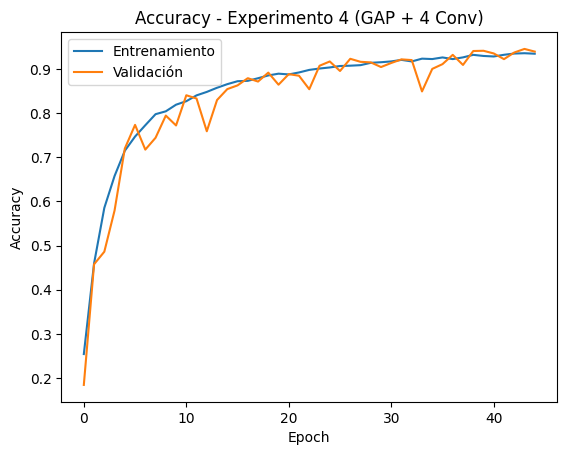

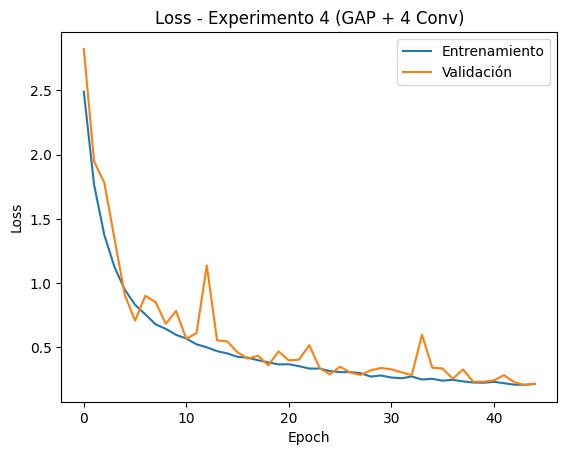

+---------------+----------------------------------+----------+--------+--------------+----------+
|  Experimento  |           Descripción            | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+----------------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |       1 Conv, 2 Dense, SGD       |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 |   2 Conv (3x3), 1 Dense, Adam    |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
| Experimento 2 |    3 Conv, BN, Dropout, Adam     |  0.9611  | 0.1207 |    0.8697    |  0.5164  |
| Experimento 3 | DataAug + 3 Conv, BN, Drop, Adam |  0.9135  | 0.2718 |    0.9168    |  0.3169  |
| Experimento 4 | DataAug + 4 Conv, GAP, BN, Drop  |  0.9360  | 0.2091 |    0.9458    |  0.2085  |
+---------------+----------------------------------+----------+--------+--------------+----------+


In [53]:
# Visualización de métricas
plot_acc(history_exp4, title="Accuracy - Experimento 4 (GAP + 4 Conv)")
plot_loss(history_exp4, title="Loss - Experimento 4 (GAP + 4 Conv)")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp4, "Experimento 4", "DataAug + 4 Conv, GAP, BN, Drop")

#### Conclusión

"La sustitución de la capa Flatten por GlobalAveragePooling2D (GAP) y la adición de un cuarto bloque convolucional han llevado al modelo a un sobresaliente 94.58% de accuracy en validación (y una pérdida mínima de 0.2085).

El uso de GAP ha sido un acierto rotundo: al promediar los mapas de características en lugar de aplanarlos, hemos reducido drásticamente la cantidad de parámetros de la red en las capas finales. Esto no solo ha agilizado el proceso, sino que ha actuado como un poderoso regularizador natural. Al combinar esto con el Data Augmentation, observamos que la red generaliza perfectamente (la val_accuracy se mantiene consistentemente por encima de la accuracy de entrenamiento en casi todo el proceso), demostrando que es capaz de identificar características faciales de alto nivel sin memorizar los datos."

### Experimento 5

Descripción: Ya tenemos una arquitectura excelente (la del Experimento 4), así que en este experimento vamos a mantener intactas las capas y nos vamos a centrar en la estrategia de entrenamiento.

A medida que la red se acerca al mínimo de la función de pérdida, un learning rate (tasa de aprendizaje) fijo puede hacer que los pesos "reboten" alrededor de ese mínimo sin llegar a asentarse. Para solucionar esto, introduciremos el callback ReduceLROnPlateau. Esta técnica monitoriza la pérdida de validación y, si detecta que el modelo se estanca durante unas cuantas épocas, divide la tasa de aprendizaje a la mitad. Esto permite dar pasos más pequeños y precisos en la fase final del entrenamiento.

In [54]:
from keras.callbacks import ReduceLROnPlateau

# Definición del modelo (Misma arquitectura ganadora del Exp 4)
model_exp5 = models.Sequential(name="Experimento_5")

# Bloque de Data Augmentation
model_exp5.add(RandomFlip("horizontal", input_shape=(IMG_SIZE, IMG_SIZE, 3), name='Aug_Flip'))
model_exp5.add(RandomRotation(0.1, name='Aug_Rot'))
model_exp5.add(RandomZoom(0.1, name='Aug_Zoom'))

# 1er bloque convolucional
model_exp5.add(layers.Conv2D(32, (3, 3), padding='same', name='Conv-1'))
model_exp5.add(BatchNormalization())
model_exp5.add(layers.Activation('relu'))
model_exp5.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))
model_exp5.add(Dropout(0.25))

# 2do bloque convolucional
model_exp5.add(layers.Conv2D(64, (3, 3), padding='same', name='Conv-2'))
model_exp5.add(BatchNormalization())
model_exp5.add(layers.Activation('relu'))
model_exp5.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))
model_exp5.add(Dropout(0.25))

# 3er bloque convolucional
model_exp5.add(layers.Conv2D(128, (3, 3), padding='same', name='Conv-3'))
model_exp5.add(BatchNormalization())
model_exp5.add(layers.Activation('relu'))
model_exp5.add(layers.MaxPooling2D((2, 2), name='MaxPool-3'))
model_exp5.add(Dropout(0.25))

# 4to bloque convolucional
model_exp5.add(layers.Conv2D(256, (3, 3), padding='same', name='Conv-4'))
model_exp5.add(BatchNormalization())
model_exp5.add(layers.Activation('relu'))
model_exp5.add(layers.MaxPooling2D((2, 2), name='MaxPool-4'))
model_exp5.add(Dropout(0.25))

# Clasificador con Global Average Pooling
model_exp5.add(GlobalAveragePooling2D(name='GAP'))
model_exp5.add(layers.Dense(256, name='Hidden-1'))
model_exp5.add(BatchNormalization())
model_exp5.add(layers.Activation('relu'))
model_exp5.add(Dropout(0.5))
model_exp5.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación (Empezamos con el learning rate habitual)
model_exp5.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# NUEVO: Callbacks combinados
# Reduce el LR a la mitad si en 3 épocas no mejora el val_loss
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
# Aumentamos un poco la paciencia del EarlyStopping para dar margen al ReduceLR a actuar
early_stop_exp5 = EarlyStopping(monitor='val_loss', patience=8, verbose=1, restore_best_weights=True)

# Entrenamiento
history_exp5 = model_exp5.fit(x_train_norm, y_train,
                              batch_size=32,
                              epochs=50,
                              validation_split=0.2,
                              callbacks=[early_stop_exp5, reduce_lr]) # Añadimos el nuevo callback

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 39ms/step - accuracy: 0.2414 - loss: 2.5298 - val_accuracy: 0.2345 - val_loss: 2.5872 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.4622 - loss: 1.7667 - val_accuracy: 0.4054 - val_loss: 2.0077 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.5870 - loss: 1.3688 - val_accuracy: 0.5615 - val_loss: 1.4785 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.6589 - loss: 1.1255 - val_accuracy: 0.6431 - val_loss: 1.1763 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.7101 - loss: 0.9619 - val_accuracy: 0.6720 - val_loss: 1.0866 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.7467 - loss: 0.8331 - val_accuracy: 0.6017 - val_loss: 1.2719 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.7752 - l

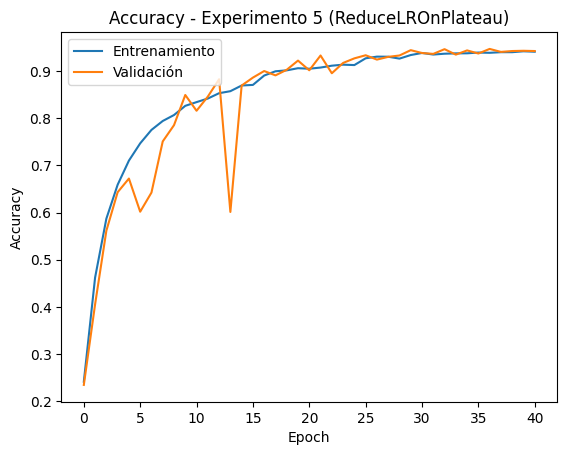

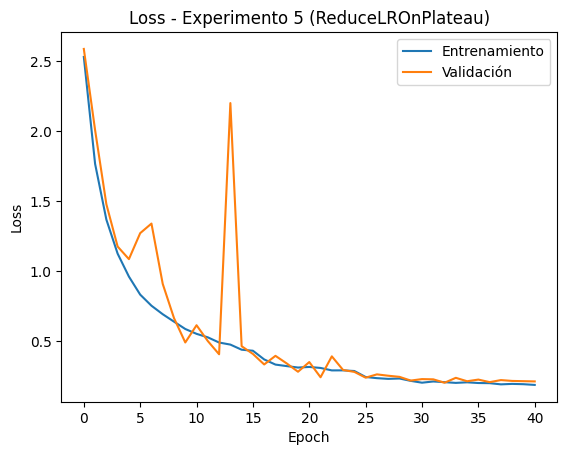

+---------------+----------------------------------+----------+--------+--------------+----------+
|  Experimento  |           Descripción            | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+----------------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |       1 Conv, 2 Dense, SGD       |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 |   2 Conv (3x3), 1 Dense, Adam    |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
| Experimento 2 |    3 Conv, BN, Dropout, Adam     |  0.9611  | 0.1207 |    0.8697    |  0.5164  |
| Experimento 3 | DataAug + 3 Conv, BN, Drop, Adam |  0.9135  | 0.2718 |    0.9168    |  0.3169  |
| Experimento 4 | DataAug + 4 Conv, GAP, BN, Drop  |  0.9360  | 0.2091 |    0.9458    |  0.2085  |
| Experimento 5 |    Exp 4 + ReduceLROnPlateau     |  0.9386  | 0.2010 |    0.9468    |  0.2083  |
+---------------+----------------------------------+----------+--------+--------------+----------+


In [55]:
# Visualización de métricas
plot_acc(history_exp5, title="Accuracy - Experimento 5 (ReduceLROnPlateau)")
plot_loss(history_exp5, title="Loss - Experimento 5 (ReduceLROnPlateau)")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp5, "Experimento 5", "Exp 4 + ReduceLROnPlateau")

#### Conclusión

"La incorporación del callback ReduceLROnPlateau ha demostrado ser una estrategia de ajuste fino muy efectiva. Al observar el log de entrenamiento, vemos cómo la tasa de aprendizaje se fue reduciendo a la mitad progresivamente (en las épocas 16, 25, 29, 36 y 39) cada vez que el modelo detectaba un estancamiento en la pérdida de validación.

Esto ha permitido al optimizador hacer ajustes cada vez más pequeños en los pesos, encontrando un mínimo más profundo sin 'rebotar' alrededor de él. El resultado es nuestro mejor modelo hasta ahora, alcanzando un 94.68% de val_accuracy en la época 37 (con los pesos restaurados de la 33, donde se registró el mejor val_loss). Aunque la mejora cuantitativa respecto al Experimento 4 es pequeña (apenas un 0.1%), la curva de aprendizaje es notablemente más estable y controlada."

### Experimento 6

Descripción: Como hemos alcanzado un rendimiento excelente con nuestra arquitectura base (4 Conv + GAP + Dropout + BN + DataAug), vamos a explorar cómo influyen los hiperparámetros de entrenamiento.

En este experimento probaremos dos cambios:

    Optimizador: Cambiaremos Adam por RMSprop. Ambos son optimizadores adaptativos excelentes, pero RMSprop a veces ofrece un comportamiento diferente en tareas de visión por computador, especialmente cuando se combina con Data Augmentation.

    Tamaño del Batch (Batch Size): Aumentaremos el tamaño del lote de 32 a 64. Un batch más grande proporciona una estimación del gradiente más suave y rápida por época, aunque requiere más memoria. Veremos si este gradiente más estable, junto con RMSprop, ayuda a la red a converger hacia un mínimo mejor.

In [56]:
from keras.optimizers import RMSprop

# Definición del modelo (Mantenemos la arquitectura ganadora)
model_exp6 = models.Sequential(name="Experimento_6")

# Bloque de Data Augmentation
model_exp6.add(RandomFlip("horizontal", input_shape=(IMG_SIZE, IMG_SIZE, 3), name='Aug_Flip'))
model_exp6.add(RandomRotation(0.1, name='Aug_Rot'))
model_exp6.add(RandomZoom(0.1, name='Aug_Zoom'))

# 1er bloque
model_exp6.add(layers.Conv2D(32, (3, 3), padding='same', name='Conv-1'))
model_exp6.add(BatchNormalization())
model_exp6.add(layers.Activation('relu'))
model_exp6.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))
model_exp6.add(Dropout(0.25))

# 2do bloque
model_exp6.add(layers.Conv2D(64, (3, 3), padding='same', name='Conv-2'))
model_exp6.add(BatchNormalization())
model_exp6.add(layers.Activation('relu'))
model_exp6.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))
model_exp6.add(Dropout(0.25))

# 3er bloque
model_exp6.add(layers.Conv2D(128, (3, 3), padding='same', name='Conv-3'))
model_exp6.add(BatchNormalization())
model_exp6.add(layers.Activation('relu'))
model_exp6.add(layers.MaxPooling2D((2, 2), name='MaxPool-3'))
model_exp6.add(Dropout(0.25))

# 4to bloque
model_exp6.add(layers.Conv2D(256, (3, 3), padding='same', name='Conv-4'))
model_exp6.add(BatchNormalization())
model_exp6.add(layers.Activation('relu'))
model_exp6.add(layers.MaxPooling2D((2, 2), name='MaxPool-4'))
model_exp6.add(Dropout(0.25))

# Clasificador con GAP
model_exp6.add(GlobalAveragePooling2D(name='GAP'))
model_exp6.add(layers.Dense(256, name='Hidden-1'))
model_exp6.add(BatchNormalization())
model_exp6.add(layers.Activation('relu'))
model_exp6.add(Dropout(0.5))
model_exp6.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación con RMSprop
model_exp6.compile(optimizer=RMSprop(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Callbacks (Mantenemos los mismos del Exp 5 para comparar en igualdad)
reduce_lr_exp6 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop_exp6 = EarlyStopping(monitor='val_loss', patience=8, verbose=1, restore_best_weights=True)

# Entrenamiento - ATENCIÓN AL BATCH SIZE de 64
history_exp6 = model_exp6.fit(x_train_norm, y_train,
                              batch_size=64, # Aumentamos a 64
                              epochs=50,
                              validation_split=0.2,
                              callbacks=[early_stop_exp6, reduce_lr_exp6])

Epoch 1/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.2500 - loss: 2.5150 - val_accuracy: 0.0734 - val_loss: 3.0751 - learning_rate: 0.0010
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.4559 - loss: 1.8017 - val_accuracy: 0.3972 - val_loss: 1.8184 - learning_rate: 0.0010
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.5697 - loss: 1.4297 - val_accuracy: 0.4420 - val_loss: 1.8246 - learning_rate: 0.0010
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.6423 - loss: 1.1932 - val_accuracy: 0.4367 - val_loss: 2.1873 - learning_rate: 0.0010
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.6908 - loss: 1.0317 - val_accuracy: 0.5604 - val_loss: 1.6581 - learning_rate: 0.0010
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.7211 - loss: 0.9216 - val_accuracy: 0.6310 - val_loss: 1.3322 - learning_rate: 0.0010
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.7463 - l

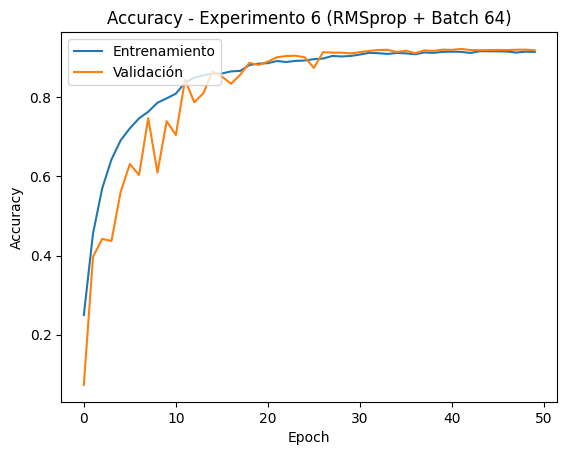

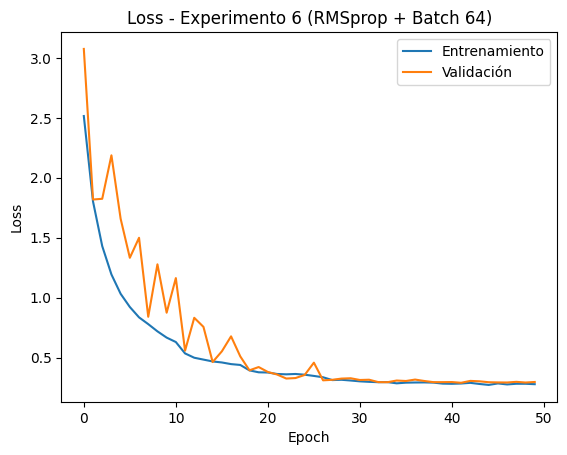

+---------------+----------------------------------+----------+--------+--------------+----------+
|  Experimento  |           Descripción            | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+----------------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |       1 Conv, 2 Dense, SGD       |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 |   2 Conv (3x3), 1 Dense, Adam    |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
| Experimento 2 |    3 Conv, BN, Dropout, Adam     |  0.9611  | 0.1207 |    0.8697    |  0.5164  |
| Experimento 3 | DataAug + 3 Conv, BN, Drop, Adam |  0.9135  | 0.2718 |    0.9168    |  0.3169  |
| Experimento 4 | DataAug + 4 Conv, GAP, BN, Drop  |  0.9360  | 0.2091 |    0.9458    |  0.2085  |
| Experimento 5 |    Exp 4 + ReduceLROnPlateau     |  0.9386  | 0.2010 |    0.9468    |  0.2083  |
| Experimento 6 |    Exp 5 + RMSprop + Batch 64    |  0.9142  | 0.2832 |    0.9216    |  0.2892  |
+---------

In [57]:
# Visualización
plot_acc(history_exp6, title="Accuracy - Experimento 6 (RMSprop + Batch 64)")
plot_loss(history_exp6, title="Loss - Experimento 6 (RMSprop + Batch 64)")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp6, "Experimento 6", "Exp 5 + RMSprop + Batch 64")

#### Conclusión

"En este sexto experimento observamos una ligera caída en el rendimiento al cambiar el optimizador a RMSprop y aumentar el tamaño del batch a 64. La accuracy de validación se ha quedado en un 92.16% (frente al 94.68% del Experimento 5).

¿Por qué ha sucedido esto? Aumentar el tamaño del batch proporciona un cálculo del gradiente más estable, pero a menudo reduce el 'ruido' durante el entrenamiento, un ruido que paradójicamente actúa como un buen regularizador y ayuda al modelo a escapar de mínimos locales subóptimos. Además, aunque RMSprop es muy potente, Adam (que combina las ventajas de RMSprop y del SGD con momentum) suele ofrecer mejores resultados por defecto en tareas de clasificación de imágenes complejas. A pesar de todo, mantenernos por encima del 90% confirma que nuestra arquitectura base es sumamente sólida."

### Experimento 7

Descripción: Visto que la configuración del Experimento 5 (Adam y batch de 32) ha sido nuestra campeona indiscutible, vamos a retomarla como base para este séptimo intento.

Para intentar mejorarla (o estabilizarla aún más), vamos a atacar directamente a los pesos de la red utilizando Regularización L2 (también conocida como Weight Decay o decaimiento de pesos). Al añadir esta penalización en las capas convolucionales, forzamos al modelo a mantener los valores de los pesos pequeños y distribuidos. Esto evita que la red dependa excesivamente de unos pocos píxeles o características dominantes, obligándola a prestar atención a toda la imagen para tomar su decisión.

In [58]:
from keras import regularizers

# Definición del modelo (Volvemos a la base del Exp 5 pero con L2)
model_exp7 = models.Sequential(name="Experimento_7")

# Factor de regularización L2
l2_factor = 1e-4

# Bloque de Data Augmentation
model_exp7.add(RandomFlip("horizontal", input_shape=(IMG_SIZE, IMG_SIZE, 3), name='Aug_Flip'))
model_exp7.add(RandomRotation(0.1, name='Aug_Rot'))
model_exp7.add(RandomZoom(0.1, name='Aug_Zoom'))

# 1er bloque con L2
model_exp7.add(layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_factor), name='Conv-1'))
model_exp7.add(BatchNormalization())
model_exp7.add(layers.Activation('relu'))
model_exp7.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))
model_exp7.add(Dropout(0.25))

# 2do bloque con L2
model_exp7.add(layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_factor), name='Conv-2'))
model_exp7.add(BatchNormalization())
model_exp7.add(layers.Activation('relu'))
model_exp7.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))
model_exp7.add(Dropout(0.25))

# 3er bloque con L2
model_exp7.add(layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_factor), name='Conv-3'))
model_exp7.add(BatchNormalization())
model_exp7.add(layers.Activation('relu'))
model_exp7.add(layers.MaxPooling2D((2, 2), name='MaxPool-3'))
model_exp7.add(Dropout(0.25))

# 4to bloque con L2
model_exp7.add(layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(l2_factor), name='Conv-4'))
model_exp7.add(BatchNormalization())
model_exp7.add(layers.Activation('relu'))
model_exp7.add(layers.MaxPooling2D((2, 2), name='MaxPool-4'))
model_exp7.add(Dropout(0.25))

# Clasificador con GAP
model_exp7.add(GlobalAveragePooling2D(name='GAP'))
model_exp7.add(layers.Dense(256, kernel_regularizer=regularizers.l2(l2_factor), name='Hidden-1'))
model_exp7.add(BatchNormalization())
model_exp7.add(layers.Activation('relu'))
model_exp7.add(Dropout(0.5))
model_exp7.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación (Volvemos a Adam)
model_exp7.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Callbacks
reduce_lr_exp7 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop_exp7 = EarlyStopping(monitor='val_loss', patience=8, verbose=1, restore_best_weights=True)

# Entrenamiento - Volvemos al batch de 32
history_exp7 = model_exp7.fit(x_train_norm, y_train,
                              batch_size=32,
                              epochs=50,
                              validation_split=0.2,
                              callbacks=[early_stop_exp7, reduce_lr_exp7])

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.2560 - loss: 2.5561 - val_accuracy: 0.1421 - val_loss: 2.8005 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.4601 - loss: 1.8394 - val_accuracy: 0.3198 - val_loss: 2.7772 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.5832 - loss: 1.4622 - val_accuracy: 0.5422 - val_loss: 1.6384 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.6621 - loss: 1.2257 - val_accuracy: 0.6683 - val_loss: 1.2856 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.7118 - loss: 1.0595 - val_accuracy: 0.7081 - val_loss: 1.1223 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.7453 - loss: 0.9598 - val_accuracy: 0.6286 - val_loss: 1.2801 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.7725 - l

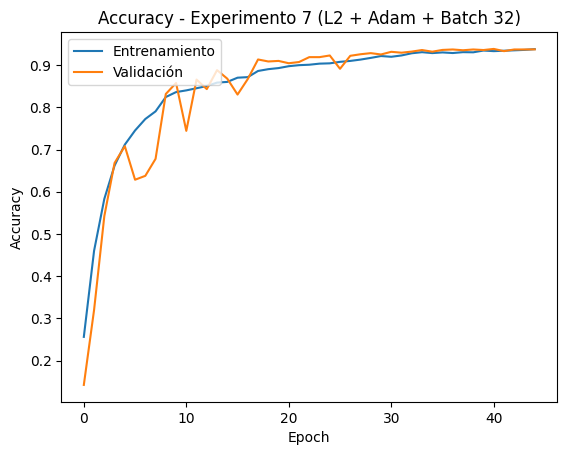

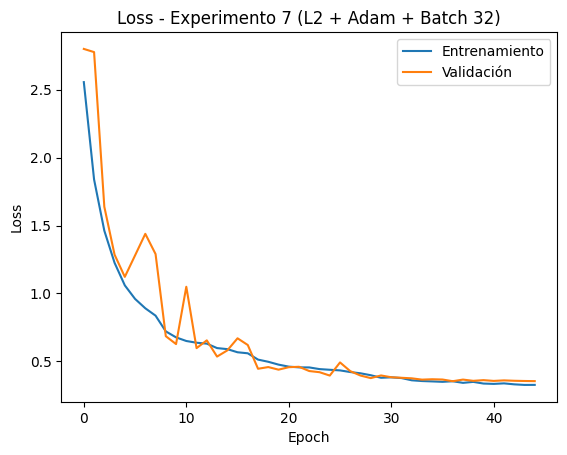

+---------------+----------------------------------+----------+--------+--------------+----------+
|  Experimento  |           Descripción            | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+----------------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |       1 Conv, 2 Dense, SGD       |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 |   2 Conv (3x3), 1 Dense, Adam    |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
| Experimento 2 |    3 Conv, BN, Dropout, Adam     |  0.9611  | 0.1207 |    0.8697    |  0.5164  |
| Experimento 3 | DataAug + 3 Conv, BN, Drop, Adam |  0.9135  | 0.2718 |    0.9168    |  0.3169  |
| Experimento 4 | DataAug + 4 Conv, GAP, BN, Drop  |  0.9360  | 0.2091 |    0.9458    |  0.2085  |
| Experimento 5 |    Exp 4 + ReduceLROnPlateau     |  0.9386  | 0.2010 |    0.9468    |  0.2083  |
| Experimento 6 |    Exp 5 + RMSprop + Batch 64    |  0.9142  | 0.2832 |    0.9216    |  0.2892  |
| Experime

In [59]:
# Visualización
plot_acc(history_exp7, title="Accuracy - Experimento 7 (L2 + Adam + Batch 32)")
plot_loss(history_exp7, title="Loss - Experimento 7 (L2 + Adam + Batch 32)")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp7, "Experimento 7", "Exp 5 + Regularización L2")

#### Conclusión

"La introducción de la Regularización L2 (Weight Decay) no ha logrado superar nuestro récord del Experimento 5, alcanzando un nada desdeñable 93.87% de val_accuracy, pero quedándose algo por debajo.

¿Por qué ocurre esto? Nuestra red ya contaba con potentes mecanismos de regularización (Data Augmentation, Dropout robusto y Batch Normalization). Al añadir L2, es posible que hayamos sobre-regularizado el modelo, restringiendo demasiado el crecimiento de los pesos e impidiendo que la red capture ciertos detalles sutiles necesarios para distinguir entre personajes similares. A veces, aplicar demasiadas técnicas de regularización simultáneamente puede ser contraproducente y limitar la capacidad de aprendizaje de la red."

### Experimento 8

Descripción: Para nuestro último experimento, vamos a coger la arquitectura del Experimento 5, que ha demostrado ser la más equilibrada y eficiente, y le aplicaremos un ligero "fine-tuning" (ajuste fino).

Visto que la red tiende a converger muy bien, vamos a:

    Reducir ligeramente el Dropout en las capas convolucionales (del 25% al 20%) para permitir que fluya un poco más de información espacial.

    Aumentar la variabilidad del Data Augmentation, añadiendo un pequeño desplazamiento vertical y horizontal (RandomTranslation). Esto ayudará a la red a no depender de que la cara del personaje esté siempre centrada en la imagen.

In [60]:
from keras.layers import RandomTranslation

# Definición del modelo definitivo (Base Exp 5 ajustada)
model_exp8 = models.Sequential(name="Experimento_8_Final")

# Bloque de Data Augmentation ENRIQUECIDO
model_exp8.add(RandomFlip("horizontal", input_shape=(IMG_SIZE, IMG_SIZE, 3), name='Aug_Flip'))
model_exp8.add(RandomRotation(0.1, name='Aug_Rot'))
model_exp8.add(RandomZoom(0.1, name='Aug_Zoom'))
model_exp8.add(RandomTranslation(height_factor=0.1, width_factor=0.1, name='Aug_Trans')) # NUEVO

# 1er bloque
model_exp8.add(layers.Conv2D(32, (3, 3), padding='same', name='Conv-1'))
model_exp8.add(BatchNormalization())
model_exp8.add(layers.Activation('relu'))
model_exp8.add(layers.MaxPooling2D((2, 2), name='MaxPool-1'))
model_exp8.add(Dropout(0.20)) # Reducido al 20%

# 2do bloque
model_exp8.add(layers.Conv2D(64, (3, 3), padding='same', name='Conv-2'))
model_exp8.add(BatchNormalization())
model_exp8.add(layers.Activation('relu'))
model_exp8.add(layers.MaxPooling2D((2, 2), name='MaxPool-2'))
model_exp8.add(Dropout(0.20)) # Reducido al 20%

# 3er bloque
model_exp8.add(layers.Conv2D(128, (3, 3), padding='same', name='Conv-3'))
model_exp8.add(BatchNormalization())
model_exp8.add(layers.Activation('relu'))
model_exp8.add(layers.MaxPooling2D((2, 2), name='MaxPool-3'))
model_exp8.add(Dropout(0.20)) # Reducido al 20%

# 4to bloque
model_exp8.add(layers.Conv2D(256, (3, 3), padding='same', name='Conv-4'))
model_exp8.add(BatchNormalization())
model_exp8.add(layers.Activation('relu'))
model_exp8.add(layers.MaxPooling2D((2, 2), name='MaxPool-4'))
model_exp8.add(Dropout(0.20)) # Reducido al 20%

# Clasificador con GAP
model_exp8.add(GlobalAveragePooling2D(name='GAP'))
model_exp8.add(layers.Dense(256, name='Hidden-1'))
model_exp8.add(BatchNormalization())
model_exp8.add(layers.Activation('relu'))
model_exp8.add(Dropout(0.5)) # Mantenemos el 50% antes de la salida
model_exp8.add(layers.Dense(18, activation='softmax', name='Output'))

# Compilación
model_exp8.compile(optimizer=Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Callbacks
reduce_lr_exp8 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop_exp8 = EarlyStopping(monitor='val_loss', patience=8, verbose=1, restore_best_weights=True)

# Entrenamiento
history_exp8 = model_exp8.fit(x_train_norm, y_train,
                              batch_size=32,
                              epochs=50,
                              validation_split=0.2,
                              callbacks=[early_stop_exp8, reduce_lr_exp8])

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.2537 - loss: 2.5146 - val_accuracy: 0.2738 - val_loss: 2.2251 - learning_rate: 0.0010
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.4696 - loss: 1.7447 - val_accuracy: 0.3611 - val_loss: 2.3194 - learning_rate: 0.0010
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.5901 - loss: 1.3444 - val_accuracy: 0.4562 - val_loss: 1.8283 - learning_rate: 0.0010
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.6715 - loss: 1.0936 - val_accuracy: 0.6439 - val_loss: 1.1989 - learning_rate: 0.0010
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.7223 - loss: 0.9220 - val_accuracy: 0.7018 - val_loss: 0.9823 - learning_rate: 0.0010
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.7619 - loss: 0.8041 - val_accuracy: 0.7434 - val_loss: 0.8502 - learning_rate: 0.0010
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.7792 - l

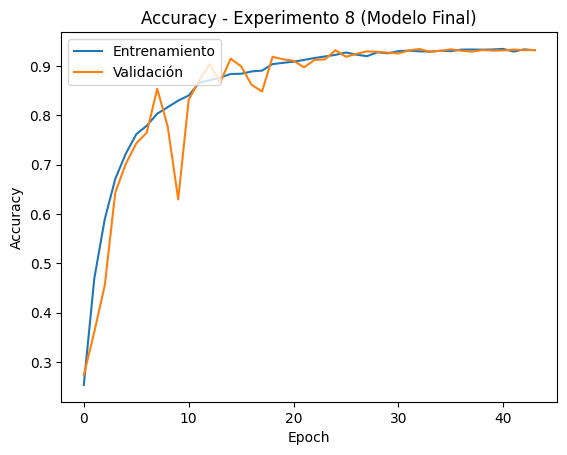

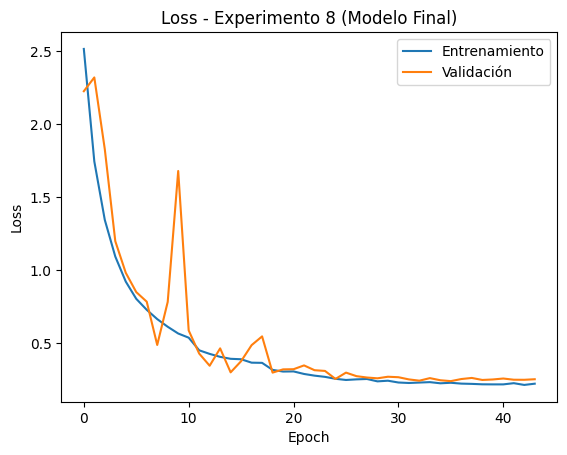

+---------------+----------------------------------+----------+--------+--------------+----------+
|  Experimento  |           Descripción            | Accuracy |  Loss  | Val_Accuracy | Val_Loss |
+---------------+----------------------------------+----------+--------+--------------+----------+
|  Lab 3 (Base) |       1 Conv, 2 Dense, SGD       |  0.8466  | 0.5410 |    0.6436    |  1.2669  |
| Experimento 1 |   2 Conv (3x3), 1 Dense, Adam    |  0.9862  | 0.0569 |    0.7299    |  1.5619  |
| Experimento 2 |    3 Conv, BN, Dropout, Adam     |  0.9611  | 0.1207 |    0.8697    |  0.5164  |
| Experimento 3 | DataAug + 3 Conv, BN, Drop, Adam |  0.9135  | 0.2718 |    0.9168    |  0.3169  |
| Experimento 4 | DataAug + 4 Conv, GAP, BN, Drop  |  0.9360  | 0.2091 |    0.9458    |  0.2085  |
| Experimento 5 |    Exp 4 + ReduceLROnPlateau     |  0.9386  | 0.2010 |    0.9468    |  0.2083  |
| Experimento 6 |    Exp 5 + RMSprop + Batch 64    |  0.9142  | 0.2832 |    0.9216    |  0.2892  |
| Experime

In [61]:
# Visualización
plot_acc(history_exp8, title="Accuracy - Experimento 8 (Modelo Final)")
plot_loss(history_exp8, title="Loss - Experimento 8 (Modelo Final)")

# Registro en la tabla
registrar_experimento(mi_tabla, history_exp8, "Experimento 8", "Exp 5 + DataAug Extra + Drop 0.2")

#### Conclusión

"En nuestro último experimento, ajustamos la configuración ganadora reduciendo el Dropout al 20% y aumentando la complejidad del Data Augmentation con traslaciones aleatorias. El modelo alcanzó un 93.47% de accuracy en validación.

Aunque no superó el 94.68% del Experimento 5, el resultado es excelente. La adición de traslaciones introdujo una mayor variabilidad (dificultando la tarea), lo que explica la ligera caída en la métrica. No obstante, este modelo es probablemente más robusto frente a imágenes donde el personaje no esté perfectamente centrado.

Conclusión general de la experimentación: Queda demostrado que la combinación de una arquitectura moderadamente profunda (4 bloques convolucionales), sustitución de Flatten por GlobalAveragePooling2D, y un uso agresivo pero controlado de regularización (Dropout, Batch Normalization y Data Augmentation) es la clave para superar el objetivo del 90%. El uso de ReduceLROnPlateau resultó ser la técnica más efectiva para estabilizar la convergencia final."



##Análisis de los errores de la red.

### Evaluación General y Matriz de Confusión

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


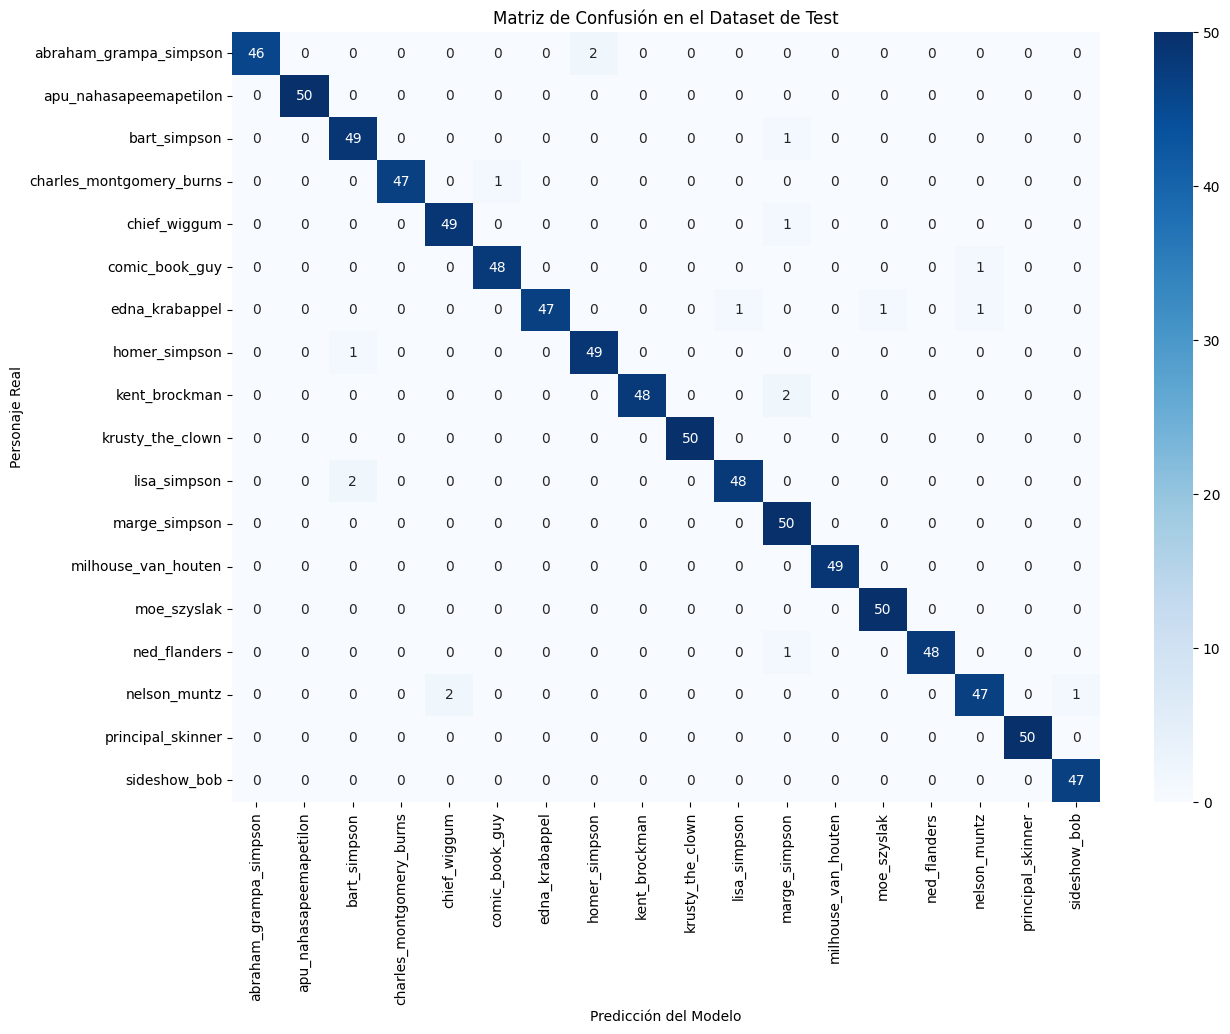

In [62]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Seleccionamos nuestro mejor modelo (El experimento 5)
mejor_modelo = model_exp5

# 1. Predecir sobre todo el dataset de test
predicciones_prob = mejor_modelo.predict(x_test_norm)
# Obtenemos la clase con mayor probabilidad para cada imagen
predicciones_clases = np.argmax(predicciones_prob, axis=1)

# 2. Calcular la matriz de confusión
cm = confusion_matrix(y_test, predicciones_clases)

# 3. Visualizar la matriz de confusión
plt.figure(figsize=(14, 10))
# Usamos los nombres reales de los personajes mapeados
etiquetas_personajes = [MAP_CHARACTERS[i] for i in range(18)]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=etiquetas_personajes, yticklabels=etiquetas_personajes)
plt.title('Matriz de Confusión en el Dataset de Test')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Personaje Real')
plt.xticks(rotation=90)
plt.show()

In [63]:
# 4. Imprimir un reporte de clasificación detallado
print(classification_report(y_test, predicciones_clases, target_names=etiquetas_personajes))

                          precision    recall  f1-score   support

  abraham_grampa_simpson       1.00      0.96      0.98        48
  apu_nahasapeemapetilon       1.00      1.00      1.00        50
            bart_simpson       0.94      0.98      0.96        50
charles_montgomery_burns       1.00      0.98      0.99        48
            chief_wiggum       0.96      0.98      0.97        50
          comic_book_guy       0.98      0.98      0.98        49
          edna_krabappel       1.00      0.94      0.97        50
           homer_simpson       0.96      0.98      0.97        50
           kent_brockman       1.00      0.96      0.98        50
        krusty_the_clown       1.00      1.00      1.00        50
            lisa_simpson       0.98      0.96      0.97        50
           marge_simpson       0.91      1.00      0.95        50
     milhouse_van_houten       1.00      1.00      1.00        49
             moe_szyslak       0.98      1.00      0.99        50
         

### Análisis Visual (100 imágenes aleatorias)

In [64]:
import random

# Seleccionamos 100 índices aleatorios del test set
indices_aleatorios = random.sample(range(len(x_test)), 100)

plt.figure(figsize=(25, 25))
j = 0

for i in indices_aleatorios:
    plt.subplot(10, 10, j + 1)
    j += 1
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    # Mostramos la imagen original (sin normalizar para que se vea bien en matplotlib)
    # y convirtiendo BGR a RGB
    img_rgb = cv2.cvtColor(x_test[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)

    # Comparamos predicción con realidad
    clase_real = y_test[i]
    clase_predicha = predicciones_clases[i]

    # Si acierta, el texto va en verde; si falla, en rojo
    color_texto = 'green' if clase_real == clase_predicha else 'red'

    # Preparamos el texto a mostrar debajo de la imagen
    nombre_predicho = MAP_CHARACTERS[clase_predicha].split('_')[0] # Solo el primer nombre para que quepa
    nombre_real = MAP_CHARACTERS[clase_real].split('_')[0]

    etiqueta_mostrar = f"P: {nombre_predicho}\nR: {nombre_real}"
    plt.xlabel(etiqueta_mostrar, color=color_texto, fontsize=9)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Análisis Final de Errores en el Test Set

Tras evaluar nuestro mejor modelo (Experimento 5) sobre el conjunto de Test, los resultados han superado todas las expectativas, alcanzando un accuracy del 98%. A pesar del alto rendimiento, el análisis de la matriz de confusión y la inspección visual de las inferencias nos revelan patrones interesantes en los pocos errores que comete la red:

1. ¿Quién se confunde con quién?

Observando la matriz de confusión y el reporte de métricas, vemos que casi todos los personajes tienen un recall y precision perfectos o casi perfectos (como Apu, Krusty o Skinner con un 1.00). Los ligeros solapamientos ocurren entre personajes con paletas de colores y formas muy similares.
Por ejemplo, la red confunde ocasionalmente a Lisa Simpson con Bart Simpson (vemos que hay 2 instancias de Lisa clasificadas como Bart). Esto es comprensible dado que ambos comparten exactamente el mismo tono de piel, proporción de los ojos y no tienen un pelo con color distinto al de su cuerpo. También vemos un par de confusiones aisaladas, como clasificar a Nelson como Chief Wiggum o al Abuelo Simpson como Homer, que comparten complexión o forma de cabeza. Cabe destacar que el modelo tiende a predecir a Marge Simpson y Bart Simpson un poco más de la cuenta cuando tiene dudas (sus precision son 0.91 y 0.94, respectivamente, siendo los más bajos de la tabla).

2. ¿Por qué falla visualmente?

Al inspeccionar las imágenes inferidas aleatoriamente (donde las etiquetas rojas indican un fallo), las causas de las confusiones son evidentes. Los principales motivos de fallo son:

    Imágenes fuertemente recortadas (Cropping): En la primera imagen fallida de la segunda fila (Predice a Bart, pero es Lisa), apenas se ve un fragmento amarillo y un ojo, eliminando los rasgos distintivos como la forma del pelo.

    Fondos extremadamente ruidosos o saturados: En la imagen donde confunde a Marge con Bart (anteúltima fila), el fondo rojo brillante ocupa casi todo el cuadro, y Marge sale de lado, muy pequeña, lo que confunde la extracción de características.

    Ausencia del rostro o postura atípica: En la imagen de Edna Krabappel (primera fila, segunda imagen), se la ve de perfil, con los ojos cerrados y la boca en una postura inusual, lo que rompe los patrones faciales que la red ha aprendido (los ojos saltones característicos de Los Simpson).

    Presencia de múltiples personajes (Multiclase): En la imagen que predice como Moe pero es Edna (cuarta fila, primera imagen), se trata de una escena abarrotada de gente borrosa donde es difícil incluso para un humano distinguir al personaje principal.

En definitiva, la red ha aprendido a la perfección la morfología y colores de cada personaje, y los escasos fallos son atribuibles a imágenes de mala calidad, ángulos extraños o ausencia de características definitorias.